<a href="https://colab.research.google.com/github/codedbyekta/AI-Model-Lab/blob/main/Phishing_Email_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('/content/meajor_cleaned_preprocessed.csv')

# Basic information
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing Values:")
display(df.isnull().sum())

print("\nLabel Distribution:")
display(df['label'].value_counts())

Dataset Shape: (108685, 20)

Columns:
['sender', 'sender_domain', 'receiver', 'receiver_domain', 'date', 'subject', 'content_types', 'body', 'urls', 'url_count', 'url_length_max', 'url_length_avg', 'url_subdom_max', 'url_subdom_avg', 'attachment_count', 'has_attachments', 'attachment_types', 'language', 'source', 'label']

First 5 rows:


,sender,sender_domain,receiver,receiver_domain,date,subject,content_types,body,urls,url_count,url_length_max,url_length_avg,url_subdom_max,url_subdom_avg,attachment_count,has_attachments,attachment_types,language,source,label
0,d66e9e64b006d6bca649f1c945129c42c43836872b2ead...,enron.com,35c5a9fb9fba3b8737ed7cef2a87e427a73db4fca85f6b...,enron.com,2001-06-29 09:37:04-05:00,[ORGANIZATION] failover plan.,text/plain,"Hi [NAME], \n\nTonight we are rolling out a n...",NaN,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,en,trec5,0.0
1,0907d5c64598aa2639154ed4e1556be615669e40052a1f...,enron.com,aa2c35499eae5999bf6080453cc719a891da2bb0c3803d...,enron.com,2001-06-29 08:39:30-05:00,RE: Intranet Site,text/plain,"[NAME] r these new?\tIntranet Site\n\n[NAME],\...",http://eastpower.dev.corp.enron.com/summary/pj...,3.0,60.0,58.0,3.0,3.0,0.0,False,NaN,en,trec5,0.0
2,7c3201a5ff8c5985218f1e3f11e330dc0242bbd28c6c20...,enron.com,a736837579feb601fbf6c0657d3d93689774afa6491bb9...,enron.com;enron.com,2001-06-29 10:35:17-05:00,FW: [ORGANIZATION] Company information,text/plain,"[NAME]/[NAME],\n\nWe are currently trading und...",NaN,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,en,trec5,0.0
3,8531d54a169c4af106b9ea2165d4986b8cc10fc0a6bb9b...,enron.com,765a3ec4a67e40118d22de5729b05d090a1b59cb443bf6...,enron.com;enron.com,2001-06-29 10:40:02-05:00,New Master Physical,text/plain,[NAME] and [NAME] -\n\nAttached is a worksheet...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,en,trec5,0.0
4,7c3201a5ff8c5985218f1e3f11e330dc0242bbd28c6c20...,enron.com,ce418c97ac415706338972e1dbbd99ebb8c617b5c937a3...,enron.com;enron.com;enron.com,2001-06-29 10:48:00-05:00,FW: [ORGANIZATION]/Mirant GISB,text/plain,FYI. Below is a copy of my communication with ...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,en,trec5,0.0



Missing Values:


,0
sender,494
sender_domain,494
receiver,2371
receiver_domain,2371
date,0
subject,1455
content_types,1
body,1
urls,44633
url_count,0



Label Distribution:


,count
label,
0.0,60650
1.0,48034


In [ ]:
print(df['label'].value_counts(normalize=True))

label
0.0    0.55804
1.0    0.44196
Name: proportion, dtype: float64


In [ ]:
display(df[['subject', 'body', 'label']].sample(10, random_state=42))

,subject,body,label
93166,Must have pills,[ORGANIZATION] is dedicated to providing you w...,1.0
17303,Re: *EMCA* Mosquitoes,All the many neighbors in the energy industry ...,0.0
40628,Where do we send the [FINANCIAL_INFO]?,"Dear Homeowner,\n\nYou have been pre-approved ...",1.0
64788,Re: svn commit: samba r[REFERENCE_NUMBER] - in...,<|EMAIL|> writes:\n\nAuthor: [NAME]\nDate: [DA...,0.0
38042,72% off for All New Software. entrepreneurial...,"Through, took house brought paint. Book busy u...",1.0
65369,Need a [ADDRESS]? We will get you the loan you...,[REFERENCE_NUMBER]\nEthnic group/ /group [ORGA...,1.0
53524,your health is your wealth,%TXT_ADD<|EMAIL_SEPARATOR|>[NAME]\nYou Will Be...,1.0
65485,"Part-Time Job Offer. [Mon, 09 Apr 2007 18:22:3...",Had she castrated the phone in case of just su...,1.0
12514,[ORGANIZATION] Personals -- 1st month free,[ORGANIZATION] Delivers\nBringing you updates ...,1.0
56894,we ship worldwide,[ORGANIZATION] - WE NEVER COMPROMISE ON QUALIT...,1.0


In [ ]:
# Handle missing values
df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')

# Combine subject and body
df['email_text'] = df['subject'] + ' ' + df['body']

# Remove empty emails
df = df[df['email_text'].str.strip() != ''].copy()

print("Dataset shape after cleaning:", df.shape)

# Check examples
display(df[['subject', 'body', 'email_text', 'label']].head())

Dataset shape after cleaning: (108685, 21)


,subject,body,email_text,label
0,[ORGANIZATION] failover plan.,"Hi [NAME], \n\nTonight we are rolling out a n...","[ORGANIZATION] failover plan. Hi [NAME], \n\n...",0.0
1,RE: Intranet Site,"[NAME] r these new?\tIntranet Site\n\n[NAME],\...",RE: Intranet Site [NAME] r these new?\tIntrane...,0.0
2,FW: [ORGANIZATION] Company information,"[NAME]/[NAME],\n\nWe are currently trading und...",FW: [ORGANIZATION] Company information [NAME]/...,0.0
3,New Master Physical,[NAME] and [NAME] -\n\nAttached is a worksheet...,New Master Physical [NAME] and [NAME] -\n\nAtt...,0.0
4,FW: [ORGANIZATION]/Mirant GISB,FYI. Below is a copy of my communication with ...,FW: [ORGANIZATION]/Mirant GISB FYI. Below is a...,0.0


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Keep only letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_text'] = df['email_text'].apply(clean_text)

display(df[['email_text', 'clean_text', 'label']].head())

,email_text,clean_text,label
0,"[ORGANIZATION] failover plan. Hi [NAME], \n\n...",organization failover plan hi name tonight we ...,0.0
1,RE: Intranet Site [NAME] r these new?\tIntrane...,re intranet site name r these new intranet sit...,0.0
2,FW: [ORGANIZATION] Company information [NAME]/...,fw organization company information name name ...,0.0
3,New Master Physical [NAME] and [NAME] -\n\nAtt...,new master physical name and name attached is ...,0.0
4,FW: [ORGANIZATION]/Mirant GISB FYI. Below is a...,fw organization mirant gisb fyi below is a cop...,0.0


In [ ]:
# Check missing labels
print("Missing labels:", df['label'].isna().sum())

# Remove rows where label is missing
df = df.dropna(subset=['label']).copy()

# Make sure labels are numeric
df['label'] = pd.to_numeric(df['label'], errors='coerce')

# Remove any labels that could not be converted
df = df.dropna(subset=['label']).copy()

# Convert labels to integer
df['label'] = df['label'].astype(int)

# Create X and y again
X = df['clean_text']
y = df['label']

print("Dataset shape:", df.shape)
print("Missing labels:", y.isna().sum())

print("\nLabel distribution:")
print(y.value_counts())

Missing labels: 1
Dataset shape: (108684, 22)
Missing labels: 0

Label distribution:
label
0    60650
1    48034
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())

Training samples: 86947
Testing samples: 21737

Training label distribution:
label
0    48520
1    38427
Name: count, dtype: int64

Testing label distribution:
label
0    12130
1     9607
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (86947, 10000)
Testing TF-IDF shape: (21737, 10000)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Create Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
lr_model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_tfidf)

# Evaluation
print("Logistic Regression Results")
print("-" * 30)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-Score :", f1_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
------------------------------
Accuracy : 0.9762156691355753
Precision: 0.971277478224803
Recall   : 0.9750182158842511
F1-Score : 0.9731442522466366

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     12130
           1       0.97      0.98      0.97      9607

    accuracy                           0.98     21737
   macro avg       0.98      0.98      0.98     21737
weighted avg       0.98      0.98      0.98     21737



Confusion Matrix:
[[11853   277]
 [  240  9367]]


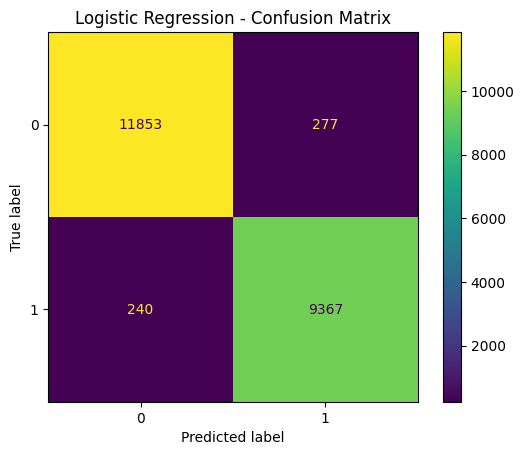

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Random Forest Results")
print("-" * 30)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-Score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
------------------------------
Accuracy : 0.9582739108432626
Precision: 0.9544504805683243
Recall   : 0.9509732486728427
F1-Score : 0.9527086917983211

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     12130
           1       0.95      0.95      0.95      9607

    accuracy                           0.96     21737
   macro avg       0.96      0.96      0.96     21737
weighted avg       0.96      0.96      0.96     21737



Random Forest Confusion Matrix:
[[11694   436]
 [  471  9136]]


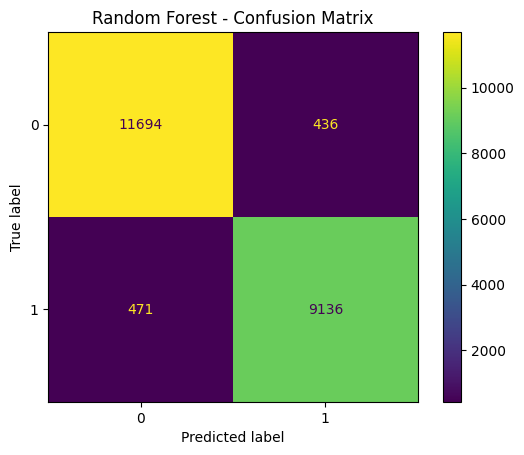

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9762,0.9713,0.975,0.9731
1,Random Forest,0.9583,0.9545,0.951,0.9527


In [ ]:
from sklearn.metrics import confusion_matrix

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

# False Negative Rate
fnr_lr = fn_lr / (fn_lr + tp_lr)
fnr_rf = fn_rf / (fn_rf + tp_rf)

print("Logistic Regression")
print("False Negatives:", fn_lr)
print("False Negative Rate:", fnr_lr)

print("\nRandom Forest")
print("False Negatives:", fn_rf)
print("False Negative Rate:", fnr_rf)

Logistic Regression
False Negatives: 240
False Negative Rate: 0.024981784115748935

Random Forest
False Negatives: 471
False Negative Rate: 0.04902675132715728


Baseline 1 is COMPLETE


In [ ]:
from sklearn.decomposition import TruncatedSVD

# Reduce TF-IDF dimensions
svd = TruncatedSVD(
    n_components=300,
    random_state=42
)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

print("Original TF-IDF shape:", X_train_tfidf.shape)
print("Reduced training shape:", X_train_svd.shape)
print("Reduced testing shape:", X_test_svd.shape)

print("Explained variance:",
      svd.explained_variance_ratio_.sum())

Original TF-IDF shape: (86947, 10000)
Reduced training shape: (86947, 300)
Reduced testing shape: (21737, 300)
Explained variance: 0.37671362939328257


In [ ]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_train_svd, y_train)

y_pred_xgb = xgb_model.predict(X_test_svd)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("XGBoost Results")
print("-" * 30)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1-Score :", f1_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
------------------------------
Accuracy : 0.9736854211712748
Precision: 0.9676016975468378
Recall   : 0.973040491308421
F1-Score : 0.9703134731160473

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     12130
           1       0.97      0.97      0.97      9607

    accuracy                           0.97     21737
   macro avg       0.97      0.97      0.97     21737
weighted avg       0.97      0.97      0.97     21737



XGBoost Confusion Matrix:
[[11817   313]
 [  259  9348]]


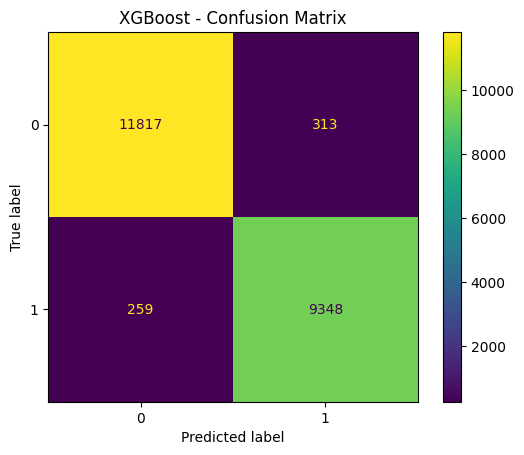

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("XGBoost Confusion Matrix:")
print(cm_xgb)

ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb
).plot()

plt.title("XGBoost - Confusion Matrix")
plt.show()

In [ ]:
# XGBoost False Negative Rate

tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()

fnr_xgb = fn_xgb / (fn_xgb + tp_xgb)

print("XGBoost")
print("False Negatives:", fn_xgb)
print("False Negative Rate:", fnr_xgb)

XGBoost
False Negatives: 259
False Negative Rate: 0.026959508691579058


Baseline 2 is DONE ✅

In [ ]:
print(df.groupby('label')['clean_text'].apply(
    lambda x: x.sample(min(3, len(x)), random_state=42)
))

label       
0      31498    re revised daily notice what does standstill f...
       91334    re passing multiple mixed arguments to subs on...
       28967    shares name good afternoon you have shares bei...
1      34786    re hot neighbour teen first time fucking perso...
       73351    urgent security notification for client of the...
       73049    i restrain ourselves camden you ve seen it bef...
Name: clean_text, dtype: object


In [ ]:
# Select phishing emails from the test set
# Based on the dataset examples, label 1 is the phishing/spam class.

phishing_test = df.loc[X_test.index].copy()
phishing_test = phishing_test[phishing_test['label'] == 1].copy()

print("Total phishing emails in test set:", len(phishing_test))

# Use a fixed sample for all evasion experiments
N = min(1000, len(phishing_test))

phishing_experiment = phishing_test.sample(
    n=N,
    random_state=42
).copy()

print("Experimental phishing emails:", len(phishing_experiment))

display(
    phishing_experiment[['subject', 'body', 'email_text', 'label']].head()
)

Total phishing emails in test set: 9607
Experimental phishing emails: 1000


,subject,body,email_text,label
23598,From [NAME] Very Urgent Reply,"Dear Friend,\n REQUEST FOR URGENT CO...","From [NAME] Very Urgent Reply Dear Friend,\n ...",1
65921,it`s [NAME],"Hi,\ni am here sitting in the internet caffe. ...","it`s [NAME] Hi,\ni am here sitting in the inte...",1
17724,Re: You have won! ...,You have been specially selected to receive a\...,Re: You have won! ...,1
108238,Viagra: buy with us and you will save your money!,[NAME] [NAME] [NAME] [NAME] [NAME]\n\n[NAME] [...,Viagra: buy with us and you will save your mon...,1
32959,Is your answer worth 10 Grand <|EMAIL|>,"[DATE] - [TIME]\n\n\nHi <|EMAIL|>,\n\n\nWho's ...",Is your answer worth 10 Grand <|EMAIL|> [DATE]...,1


In [ ]:
# Original phishing emails
original_text = phishing_experiment['email_text']

# Apply the same preprocessing used during baseline training
original_clean = original_text.apply(clean_text)

# Transform using already-fitted TF-IDF
original_tfidf = tfidf.transform(original_clean)

# Logistic Regression prediction
original_pred = lr_model.predict(original_tfidf)

# 1 = detected as phishing
detected = (original_pred == 1).sum()

# 0 = predicted as legitimate -> potential false negative
bypassed = (original_pred == 0).sum()

baseline_bypass_rate = bypassed / len(original_pred)

print("Original Phishing Emails:", len(original_pred))
print("Detected as Phishing:", detected)
print("Predicted as Legitimate:", bypassed)
print("Baseline False Negative Rate:", baseline_bypass_rate)

Original Phishing Emails: 1000
Detected as Phishing: 975
Predicted as Legitimate: 25
Baseline False Negative Rate: 0.025


In [ ]:
import re
import random

random.seed(42)

def apply_misspelling(text, probability=0.15):
    """
    Introduce controlled character-level misspellings
    into alphabetic words.
    """
    words = str(text).split()
    modified_words = []

    for word in words:
        # Only modify sufficiently long alphabetic words
        if len(word) >= 5 and word.isalpha() and random.random() < probability:
            pos = random.randint(1, len(word) - 2)

            # Remove one character
            word = word[:pos] + word[pos+1:]

        modified_words.append(word)

    return " ".join(modified_words)


# Apply misspelling to the same 1000 phishing emails
phishing_experiment['misspelled_text'] = (
    phishing_experiment['email_text']
    .apply(apply_misspelling)
)

display(
    phishing_experiment[
        ['email_text', 'misspelled_text']
    ].head(5)
)

,email_text,misspelled_text
23598,"From [NAME] Very Urgent Reply Dear Friend,\n ...","From [NAME] Very Urgent Rely Dear Friend, REQU..."
65921,"it`s [NAME] Hi,\ni am here sitting in the inte...","it`s [NAME] Hi, i am here sitting in the inter..."
17724,Re: You have won! ...,Re: You have won! 45 You have been specially s...
108238,Viagra: buy with us and you will save your mon...,Viagra: buy with us and you will save your mon...
32959,Is your answer worth 10 Grand <|EMAIL|> [DATE]...,Is your aswer worth 10 Grand <|EMAIL|> [DATE] ...


In [ ]:
# Preprocess the misspelled emails
misspelled_clean = (
    phishing_experiment['misspelled_text']
    .apply(clean_text)
)

# Convert using the SAME TF-IDF vectorizer
misspelled_tfidf = tfidf.transform(misspelled_clean)

# Predict using the SAME trained Logistic Regression model
misspelled_pred = lr_model.predict(misspelled_tfidf)

# Calculate detected and bypassed emails
misspell_detected = (misspelled_pred == 1).sum()
misspell_bypassed = (misspelled_pred == 0).sum()

# Calculate bypass rate
misspell_bypass_rate = (
    misspell_bypassed / len(misspelled_pred)
)

print("Misspelling Evasion Results")
print("-" * 35)
print("Emails Tested:", len(misspelled_pred))
print("Detected as Phishing:", misspell_detected)
print("Predicted as Legitimate:", misspell_bypassed)
print("Bypass Rate:", misspell_bypass_rate)
print("Bypass Rate (%):", misspell_bypass_rate * 100)

Misspelling Evasion Results
-----------------------------------
Emails Tested: 1000
Detected as Phishing: 973
Predicted as Legitimate: 27
Bypass Rate: 0.027
Bypass Rate (%): 2.7


Perfect ✅ Technique 1 — Misspelling Evasion complete.

In [ ]:
import random

random.seed(42)

rewrite_map = {
    "urgent": "important",
    "immediately": "quickly",
    "click": "select",
    "account": "profile",
    "verify": "confirm",
    "verification": "confirmation",
    "password": "passcode",
    "offer": "deal",
    "winner": "recipient",
    "free": "complimentary",
    "payment": "transaction",
    "money": "funds",
    "security": "protection",
    "confirm": "validate",
    "receive": "get"
}

def apply_text_rewriting(text, probability=0.25):
    words = str(text).split()
    modified_words = []

    for word in words:
        # Preserve punctuation while matching the word
        clean_word = word.lower().strip(".,!?;:()[]{}\"'")

        if clean_word in rewrite_map and random.random() < probability:
            replacement = rewrite_map[clean_word]

            # Preserve simple capitalization
            if word[:1].isupper():
                replacement = replacement.capitalize()

            modified_words.append(replacement)
        else:
            modified_words.append(word)

    return " ".join(modified_words)


phishing_experiment['rewritten_text'] = (
    phishing_experiment['email_text']
    .apply(apply_text_rewriting)
)

display(
    phishing_experiment[
        ['email_text', 'rewritten_text']
    ].head(5)
)

,email_text,rewritten_text
23598,"From [NAME] Very Urgent Reply Dear Friend,\n ...","From [NAME] Very Urgent Reply Dear Friend, REQ..."
65921,"it`s [NAME] Hi,\ni am here sitting in the inte...","it`s [NAME] Hi, i am here sitting in the inter..."
17724,Re: You have won! ...,Re: You have won! 45 You have been specially s...
108238,Viagra: buy with us and you will save your mon...,Viagra: buy with us and you will save your mon...
32959,Is your answer worth 10 Grand <|EMAIL|> [DATE]...,Is your answer worth 10 Grand <|EMAIL|> [DATE]...


In [ ]:
# Preprocess rewritten emails
rewritten_clean = (
    phishing_experiment['rewritten_text']
    .apply(clean_text)
)

# Use the SAME fitted TF-IDF vectorizer
rewritten_tfidf = tfidf.transform(rewritten_clean)

# Use the SAME trained Logistic Regression model
rewritten_pred = lr_model.predict(rewritten_tfidf)

# Calculate results
rewrite_detected = (rewritten_pred == 1).sum()
rewrite_bypassed = (rewritten_pred == 0).sum()

rewrite_bypass_rate = (
    rewrite_bypassed / len(rewritten_pred)
)

print("Text Rewriting Evasion Results")
print("-" * 40)
print("Emails Tested:", len(rewritten_pred))
print("Detected as Phishing:", rewrite_detected)
print("Predicted as Legitimate:", rewrite_bypassed)
print("Bypass Rate:", rewrite_bypass_rate)
print("Bypass Rate (%):", rewrite_bypass_rate * 100)

Text Rewriting Evasion Results
----------------------------------------
Emails Tested: 1000
Detected as Phishing: 975
Predicted as Legitimate: 25
Bypass Rate: 0.025
Bypass Rate (%): 2.5


Perfect ✅ Technique 2 — Text Rewriting complete.

In [ ]:
def clean_text_url_aware(text):
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Keep URLs, words, numbers and basic URL characters
    text = re.sub(r'[^a-z0-9\s:/._?=&%-]', ' ', text)

    # Normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Check original examples
url_aware_original = (
    phishing_experiment['email_text']
    .apply(clean_text_url_aware)
)

display(
    url_aware_original.head(5)
)

,email_text
23598,from name very urgent reply dear friend reques...
65921,it s name hi i am here sitting in the internet...
17724,re: you have won 45 you have been specially se...
108238,viagra: buy with us and you will save your mon...
32959,is your answer worth 10 grand date - time hi w...


In [ ]:
import re

def has_url(text):
    return bool(
        re.search(
            r'(https?://|www\.)\S+',
            str(text),
            flags=re.IGNORECASE
        )
    )

phishing_experiment['has_url'] = (
    phishing_experiment['email_text'].apply(has_url)
)

print("Phishing emails with URL:",
      phishing_experiment['has_url'].sum())

print("Phishing emails without URL:",
      (~phishing_experiment['has_url']).sum())

Phishing emails with URL: 0
Phishing emails without URL: 1000


In [ ]:
import random

random.seed(42)

def apply_character_insertion(text, probability=0.15):
    words = str(text).split()
    modified_words = []

    for word in words:
        if len(word) >= 5 and word.isalpha() and random.random() < probability:
            pos = random.randint(1, len(word) - 1)

            # Insert a duplicate character
            word = word[:pos] + word[pos-1] + word[pos:]

        modified_words.append(word)

    return " ".join(modified_words)


phishing_experiment['char_inserted_text'] = (
    phishing_experiment['email_text']
    .apply(apply_character_insertion)
)

display(
    phishing_experiment[
        ['email_text', 'char_inserted_text']
    ].head(5)
)

,email_text,char_inserted_text
23598,"From [NAME] Very Urgent Reply Dear Friend,\n ...","From [NAME] Very Urgent Repply Dear Friend, RE..."
65921,"it`s [NAME] Hi,\ni am here sitting in the inte...","it`s [NAME] Hi, i am here sittinng in the inte..."
17724,Re: You have won! ...,Re: You have won! 45 You have been specially s...
108238,Viagra: buy with us and you will save your mon...,Viagra: buy with us and you will save your mon...
32959,Is your answer worth 10 Grand <|EMAIL|> [DATE]...,Is your answer wworth 10 Grand <|EMAIL|> [DATE...


In [ ]:
# Preprocess character-inserted emails
char_inserted_clean = (
    phishing_experiment['char_inserted_text']
    .apply(clean_text)
)

# Use the SAME fitted TF-IDF vectorizer
char_inserted_tfidf = tfidf.transform(char_inserted_clean)

# Use the SAME trained Logistic Regression model
char_inserted_pred = lr_model.predict(char_inserted_tfidf)

# Calculate results
char_inserted_detected = (char_inserted_pred == 1).sum()
char_inserted_bypassed = (char_inserted_pred == 0).sum()

char_inserted_bypass_rate = (
    char_inserted_bypassed / len(char_inserted_pred)
)

print("Character Insertion Evasion Results")
print("-" * 45)
print("Emails Tested:", len(char_inserted_pred))
print("Detected as Phishing:", char_inserted_detected)
print("Predicted as Legitimate:", char_inserted_bypassed)
print("Bypass Rate:", char_inserted_bypass_rate)
print("Bypass Rate (%):", char_inserted_bypass_rate * 100)

Character Insertion Evasion Results
---------------------------------------------
Emails Tested: 1000
Detected as Phishing: 976
Predicted as Legitimate: 24
Bypass Rate: 0.024
Bypass Rate (%): 2.4


Perfect ✅ Technique 3 — Character Insertion complete.


In [ ]:
import random

random.seed(42)

word_substitution_map = {
    "urgent": "critical",
    "important": "essential",
    "click": "press",
    "account": "profile",
    "verify": "validate",
    "verification": "validation",
    "password": "credential",
    "offer": "promotion",
    "winner": "recipient",
    "free": "complimentary",
    "payment": "transaction",
    "money": "funds",
    "security": "safety",
    "confirm": "validate",
    "receive": "obtain",
    "message": "notice",
    "information": "details"
}

def apply_word_substitution(text, probability=0.30):
    words = str(text).split()
    modified_words = []

    for word in words:
        clean_word = word.lower().strip(".,!?;:()[]{}\"'")

        if clean_word in word_substitution_map and random.random() < probability:
            replacement = word_substitution_map[clean_word]

            if word[:1].isupper():
                replacement = replacement.capitalize()

            modified_words.append(replacement)
        else:
            modified_words.append(word)

    return " ".join(modified_words)


phishing_experiment['substituted_text'] = (
    phishing_experiment['email_text']
    .apply(apply_word_substitution)
)

display(
    phishing_experiment[
        ['email_text', 'substituted_text']
    ].head(5)
)

,email_text,substituted_text
23598,"From [NAME] Very Urgent Reply Dear Friend,\n ...","From [NAME] Very Urgent Reply Dear Friend, REQ..."
65921,"it`s [NAME] Hi,\ni am here sitting in the inte...","it`s [NAME] Hi, i am here sitting in the inter..."
17724,Re: You have won! ...,Re: You have won! 45 You have been specially s...
108238,Viagra: buy with us and you will save your mon...,Viagra: buy with us and you will save your fun...
32959,Is your answer worth 10 Grand <|EMAIL|> [DATE]...,Is your answer worth 10 Grand <|EMAIL|> [DATE]...


In [ ]:
# Preprocess substituted emails
substituted_clean = (
    phishing_experiment['substituted_text']
    .apply(clean_text)
)

# Use the SAME fitted TF-IDF vectorizer
substituted_tfidf = tfidf.transform(substituted_clean)

# Use the SAME trained Logistic Regression model
substituted_pred = lr_model.predict(substituted_tfidf)

# Calculate results
substitution_detected = (substituted_pred == 1).sum()
substitution_bypassed = (substituted_pred == 0).sum()

substitution_bypass_rate = (
    substitution_bypassed / len(substituted_pred)
)

print("Word Substitution Evasion Results")
print("-" * 45)
print("Emails Tested:", len(substituted_pred))
print("Detected as Phishing:", substitution_detected)
print("Predicted as Legitimate:", substitution_bypassed)
print("Bypass Rate:", substitution_bypass_rate)
print("Bypass Rate (%):", substitution_bypass_rate * 100)

Word Substitution Evasion Results
---------------------------------------------
Emails Tested: 1000
Detected as Phishing: 975
Predicted as Legitimate: 25
Bypass Rate: 0.025
Bypass Rate (%): 2.5


Perfect ✅ Technique 4 — Word Substitution complete.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

evasion_results = pd.DataFrame({
    'Technique': [
        'Original',
        'Misspelling',
        'Text Rewriting',
        'Character Insertion',
        'Word Substitution'
    ],
    'Emails Tested': [
        1000, 1000, 1000, 1000, 1000
    ],
    'Detected': [
        detected,
        misspell_detected,
        rewrite_detected,
        char_inserted_detected,
        substitution_detected
    ],
    'Bypassed': [
        bypassed,
        misspell_bypassed,
        rewrite_bypassed,
        char_inserted_bypassed,
        substitution_bypassed
    ],
    'Bypass Rate (%)': [
        baseline_bypass_rate * 100,
        misspell_bypass_rate * 100,
        rewrite_bypass_rate * 100,
        char_inserted_bypass_rate * 100,
        substitution_bypass_rate * 100
    ]
})

display(evasion_results)

,Technique,Emails Tested,Detected,Bypassed,Bypass Rate (%)
0,Original,1000,975,25,2.5
1,Misspelling,1000,973,27,2.7
2,Text Rewriting,1000,975,25,2.5
3,Character Insertion,1000,976,24,2.4
4,Word Substitution,1000,975,25,2.5


In [ ]:
# Exclude Original when finding the strongest evasion technique
technique_results = evasion_results[
    evasion_results['Technique'] != 'Original'
]

highest_evasion = technique_results.loc[
    technique_results['Bypass Rate (%)'].idxmax()
]

print("Highest Evasion Technique")
print("-" * 35)
print("Technique:", highest_evasion['Technique'])
print("Bypass Rate:", highest_evasion['Bypass Rate (%)'], "%")
print("Emails Bypassed:", highest_evasion['Bypassed'])

Highest Evasion Technique
-----------------------------------
Technique: Misspelling
Bypass Rate: 2.7 %
Emails Bypassed: 27


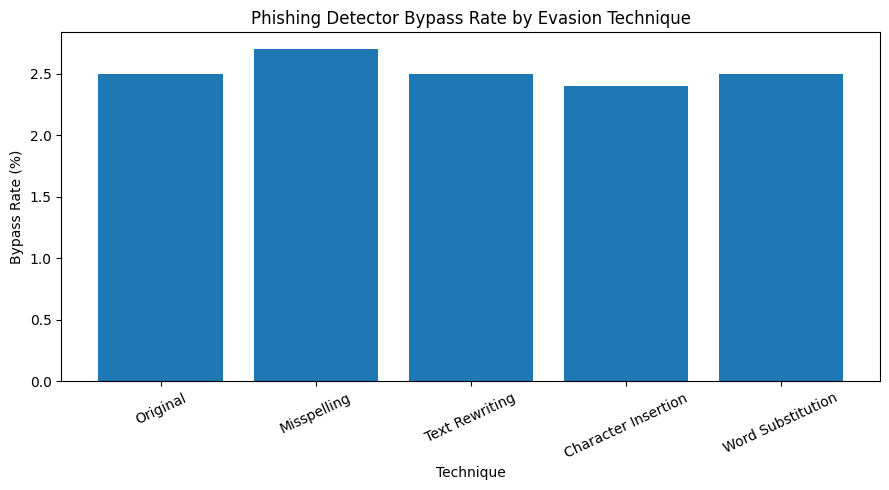

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    evasion_results['Technique'],
    evasion_results['Bypass Rate (%)']
)

plt.xlabel("Technique")
plt.ylabel("Bypass Rate (%)")
plt.title("Phishing Detector Bypass Rate by Evasion Technique")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [ ]:
# Function to test any transformed text using the existing XGBoost model

def evaluate_xgb_evasion(text_series, technique_name):

    # Same preprocessing used for the baseline
    cleaned = text_series.apply(clean_text)

    # Same fitted TF-IDF vectorizer
    tfidf_features = tfidf.transform(cleaned)

    # Same fitted SVD transformation
    svd_features = svd.transform(tfidf_features)

    # Same trained XGBoost model
    predictions = xgb_model.predict(svd_features)

    detected = (predictions == 1).sum()
    bypassed = (predictions == 0).sum()
    bypass_rate = bypassed / len(predictions)

    return {
        'Technique': technique_name,
        'Emails Tested': len(predictions),
        'Detected': detected,
        'Bypassed': bypassed,
        'Bypass Rate (%)': bypass_rate * 100
    }


# Evaluate all available transformations
xgb_results = []

xgb_results.append(
    evaluate_xgb_evasion(
        phishing_experiment['email_text'],
        'Original'
    )
)

xgb_results.append(
    evaluate_xgb_evasion(
        phishing_experiment['misspelled_text'],
        'Misspelling'
    )
)

xgb_results.append(
    evaluate_xgb_evasion(
        phishing_experiment['rewritten_text'],
        'Text Rewriting'
    )
)

xgb_results.append(
    evaluate_xgb_evasion(
        phishing_experiment['char_inserted_text'],
        'Character Insertion'
    )
)

xgb_results.append(
    evaluate_xgb_evasion(
        phishing_experiment['substituted_text'],
        'Word Substitution'
    )
)


xgb_evasion_results = pd.DataFrame(xgb_results)

display(xgb_evasion_results)

,Technique,Emails Tested,Detected,Bypassed,Bypass Rate (%)
0,Original,1000,977,23,2.3
1,Misspelling,1000,974,26,2.6
2,Text Rewriting,1000,975,25,2.5
3,Character Insertion,1000,976,24,2.4
4,Word Substitution,1000,976,24,2.4


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    'Technique': [
        'Original',
        'Misspelling',
        'Text Rewriting',
        'Character Insertion',
        'Word Substitution'
    ],
    'Logistic Regression': [
        baseline_bypass_rate * 100,
        misspell_bypass_rate * 100,
        rewrite_bypass_rate * 100,
        char_inserted_bypass_rate * 100,
        substitution_bypass_rate * 100
    ],
    'XGBoost': [
        2.3,
        2.6,
        2.5,
        2.4,
        2.4
    ]
})

display(comparison)

,Technique,Logistic Regression,XGBoost
0,Original,2.5,2.3
1,Misspelling,2.7,2.6
2,Text Rewriting,2.5,2.5
3,Character Insertion,2.4,2.4
4,Word Substitution,2.5,2.4


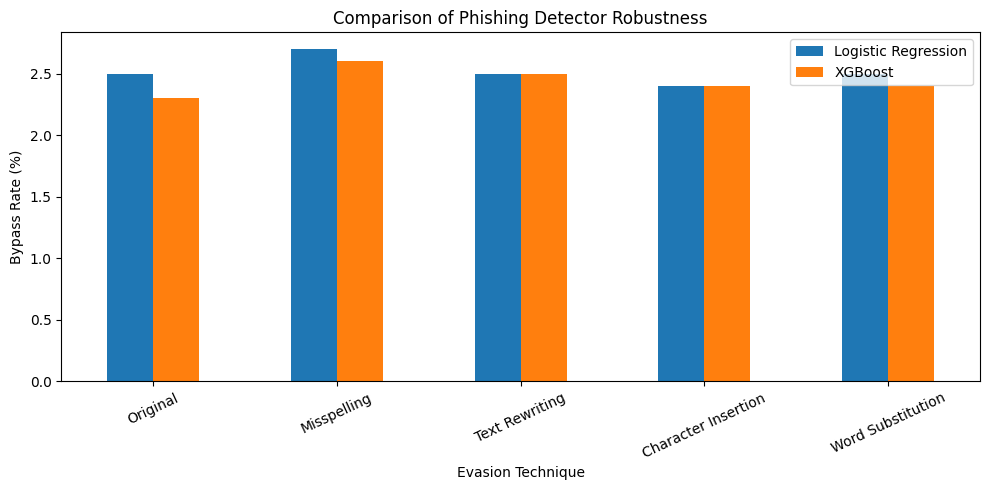

In [ ]:
comparison_plot = comparison.set_index('Technique')

comparison_plot.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.xlabel("Evasion Technique")
plt.ylabel("Bypass Rate (%)")
plt.title("Comparison of Phishing Detector Robustness")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [ ]:
# Find phishing emails that were detected originally
# but bypassed after misspelling

error_analysis = phishing_experiment[
    (original_pred == 1) &
    (misspelled_pred == 0)
].copy()

print("Emails bypassed specifically after misspelling:",
      len(error_analysis))

display(
    error_analysis[
        ['email_text', 'misspelled_text']
    ].head(10)
)

Emails bypassed specifically after misspelling: 2


,email_text,misspelled_text
90167,Your HousePmt Could Be Cut in Half adf HTML Me...,Your HousePmt Could Be Cut in Half adf HTML Me...
89308,Question from [USERNAME] [ORGANIZATION]\nsent ...,Quetion from [USERNAME] [ORGANIZATION] sent th...


In [ ]:
# Analyze the newly bypassed emails

error_analysis['original_length'] = (
    error_analysis['email_text']
    .astype(str)
    .str.len()
)

error_analysis['misspelled_length'] = (
    error_analysis['misspelled_text']
    .astype(str)
    .str.len()
)

error_analysis['word_count'] = (
    error_analysis['email_text']
    .astype(str)
    .str.split()
    .str.len()
)

# Check for common email characteristics
error_analysis['contains_url'] = (
    error_analysis['email_text']
    .astype(str)
    .str.contains(
        r'https?://|www\.',
        case=False,
        regex=True
    )
)

error_analysis['contains_html'] = (
    error_analysis['email_text']
    .astype(str)
    .str.contains(
        r'<[^>]+>',
        regex=True
    )
)

display(
    error_analysis[
        [
            'original_length',
            'word_count',
            'contains_url',
            'contains_html'
        ]
    ]
)

,original_length,word_count,contains_url,contains_html
90167,363,60,False,True
89308,2068,296,False,True


In [ ]:
# Display the two newly bypassed emails in a readable format

for idx, row in error_analysis.iterrows():
    print("=" * 80)
    print("Email ID:", idx)
    print("\nOriginal:")
    print(row['email_text'][:1500])
    print("\nAfter Misspelling:")
    print(row['misspelled_text'][:1500])
    print()

Email ID: 90167

Original:
Your HousePmt Could Be Cut in Half adf HTML Message - Your HousePmt Could Be Cut in Half adf<|EMAIL_SEPARATOR|>Cut your house pmt way down the Christian Way
To stop receiving [ORGANIZATION] email offers, advertisements and promotions, go to unsubscribe here to go to the home page of [ORGANIZATION] and click on the ÂUnsubscribeÂ link at the bottom of the page.

After Misspelling:
Your HousePmt Could Be Cut in Half adf HTML Message - Your HousePmt Could Be Cut in Half adf<|EMAIL_SEPARATOR|>Cut your house pmt way down the Christin Way To stop reciving [ORGANIZATION] email offers, advertisements and promotions, go to unsubscribe here to go to the home page of [ORGANIZATION] and click on the ÂUnsubscribeÂ link at the botom of the page.

Email ID: 89308

Original:
Question from [USERNAME] [ORGANIZATION]
sent this message to you.
Question about Item -- Respond Now
[ORGANIZATION] sent this message on behalf of an [ORGANIZATION] member through My Messages. Respons

In [ ]:
# Quantify the impact of misspelling

original_detected = (original_pred == 1).sum()
misspelled_detected = (misspelled_pred == 1).sum()

original_bypass = (original_pred == 0).sum()
misspelled_bypass = (misspelled_pred == 0).sum()

newly_bypassed = (
    (original_pred == 1) &
    (misspelled_pred == 0)
).sum()

recovered = (
    (original_pred == 0) &
    (misspelled_pred == 1)
).sum()

print("Original detected:", original_detected)
print("Misspelled detected:", misspelled_detected)
print("Original bypassed:", original_bypass)
print("Misspelled bypassed:", misspelled_bypass)
print("Newly bypassed due to misspelling:", newly_bypassed)
print("Previously bypassed but detected after misspelling:", recovered)
print("Net change in bypassed emails:",
      misspelled_bypass - original_bypass)

Original detected: 975
Misspelled detected: 973
Original bypassed: 25
Misspelled bypassed: 27
Newly bypassed due to misspelling: 2
Previously bypassed but detected after misspelling: 0
Net change in bypassed emails: 2


Feature Analysis

In [ ]:
# Get TF-IDF feature names and Logistic Regression coefficients

feature_names = tfidf.get_feature_names_out()
lr_coefficients = lr_model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_coefficients,
    'Absolute_Coefficient': abs(lr_coefficients)
}).sort_values(
    'Absolute_Coefficient',
    ascending=False
)

display(feature_importance.head(30))

,Feature,Coefficient,Absolute_Coefficient
7977,thanks,-7.566718,7.566718
3137,fw,-7.074200,7.074200
8051,the,-6.357531,6.357531
9763,wrote,-5.891795,5.891795
182,ae,5.842524,5.842524
812,attached,-5.842475,5.842475
4476,list,-5.485022,5.485022
7983,thanks name,-5.072868,5.072868
2927,for,-4.886421,4.886421
9906,your,4.757528,4.757528


In [ ]:
# Analyze the 2 newly bypassed emails

for idx in error_analysis.index:

    original = original_clean.loc[idx]
    misspelled = misspelled_clean.loc[idx]

    original_features = set(
        tfidf.transform([original]).nonzero()[1]
    )

    misspelled_features = set(
        tfidf.transform([misspelled]).nonzero()[1]
    )

    lost_features = original_features - misspelled_features
    retained_features = original_features & misspelled_features

    print("=" * 80)
    print("Email ID:", idx)

    print("\nOriginal prediction:", original_pred[phishing_experiment.index.get_loc(idx)])
    print("Misspelled prediction:", misspelled_pred[phishing_experiment.index.get_loc(idx)])

    print("\nOriginal text:")
    print(phishing_experiment.loc[idx, 'email_text'][:1000])

    print("\nMisspelled text:")
    print(phishing_experiment.loc[idx, 'misspelled_text'][:1000])

    print("\nNumber of TF-IDF features:")
    print("Original:", len(original_features))
    print("After misspelling:", len(misspelled_features))
    print("Features lost:", len(lost_features))

    print("\nLost TF-IDF features:")
    print([feature_names[i] for i in sorted(lost_features)][:50])

Email ID: 90167

Original prediction: 1
Misspelled prediction: 0

Original text:
Your HousePmt Could Be Cut in Half adf HTML Message - Your HousePmt Could Be Cut in Half adf<|EMAIL_SEPARATOR|>Cut your house pmt way down the Christian Way
To stop receiving [ORGANIZATION] email offers, advertisements and promotions, go to unsubscribe here to go to the home page of [ORGANIZATION] and click on the ÂUnsubscribeÂ link at the bottom of the page.

Misspelled text:
Your HousePmt Could Be Cut in Half adf HTML Message - Your HousePmt Could Be Cut in Half adf<|EMAIL_SEPARATOR|>Cut your house pmt way down the Christin Way To stop reciving [ORGANIZATION] email offers, advertisements and promotions, go to unsubscribe here to go to the home page of [ORGANIZATION] and click on the ÂUnsubscribeÂ link at the botom of the page.

Number of TF-IDF features:
Original: 53
After misspelling: 47
Features lost: 6

Lost TF-IDF features:
['bottom', 'bottom of', 'christian', 'receiving', 'stop receiving', 'the 

In [ ]:
# Compare Logistic Regression decision scores
# before and after misspelling

original_scores = lr_model.decision_function(original_tfidf)
misspelled_scores = lr_model.decision_function(misspelled_tfidf)

score_comparison = pd.DataFrame({
    'Email_ID': phishing_experiment.index,
    'Original_Score': original_scores,
    'Misspelled_Score': misspelled_scores,
    'Score_Change': misspelled_scores - original_scores,
    'Original_Prediction': original_pred,
    'Misspelled_Prediction': misspelled_pred
})

# Only the newly bypassed emails
score_comparison[
    (score_comparison['Original_Prediction'] == 1) &
    (score_comparison['Misspelled_Prediction'] == 0)
]

,Email_ID,Original_Score,Misspelled_Score,Score_Change,Original_Prediction,Misspelled_Prediction
147,90167,0.299067,-0.391634,-0.690701,1,0
237,89308,0.592325,-0.012177,-0.604502,1,0


In [ ]:
# Create augmented training data using misspelling perturbation

X_train_aug = X_train.copy()
y_train_aug = y_train.copy()

# Create a controlled subset of phishing training emails
phishing_train = df.loc[X_train.index]
phishing_train = phishing_train[phishing_train['label'] == 1]

# Use a fixed subset for augmentation
N_AUG = min(5000, len(phishing_train))

phishing_train_aug = phishing_train.sample(
    n=N_AUG,
    random_state=42
).copy()

# Apply misspelling perturbation
phishing_train_aug['augmented_text'] = (
    phishing_train_aug['email_text']
    .apply(apply_misspelling)
)

# Combine original + augmented phishing samples
X_augmented = pd.concat([
    X_train,
    phishing_train_aug['augmented_text']
], ignore_index=True)

y_augmented = pd.concat([
    y_train,
    pd.Series(
        [1] * len(phishing_train_aug)
    )
], ignore_index=True)

print("Original training samples:", len(X_train))
print("Augmented samples:", len(phishing_train_aug))
print("Final training samples:", len(X_augmented))
print("Phishing augmented samples:", (y_augmented == 1).sum())

Original training samples: 86947
Augmented samples: 5000
Final training samples: 91947
Phishing augmented samples: 43427


In [ ]:
# Train Robust Logistic Regression with augmented data

robust_tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Fit TF-IDF on augmented training data
X_aug_tfidf = robust_tfidf.fit_transform(X_augmented)

print("Augmented TF-IDF shape:", X_aug_tfidf.shape)

# Train robust Logistic Regression
robust_lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

robust_lr_model.fit(X_aug_tfidf, y_augmented)

print("Robust Logistic Regression trained successfully!")

Augmented TF-IDF shape: (91947, 10000)
Robust Logistic Regression trained successfully!


In [ ]:
# Evaluate Robust Logistic Regression
# on original and misspelled phishing emails

# Original phishing emails
original_robust_tfidf = robust_tfidf.transform(original_clean)

original_robust_pred = robust_lr_model.predict(
    original_robust_tfidf
)

# Misspelled phishing emails
misspelled_robust_tfidf = robust_tfidf.transform(misspelled_clean)

misspelled_robust_pred = robust_lr_model.predict(
    misspelled_robust_tfidf
)

# Calculate results
original_robust_detected = (original_robust_pred == 1).sum()
original_robust_bypassed = (original_robust_pred == 0).sum()

misspelled_robust_detected = (misspelled_robust_pred == 1).sum()
misspelled_robust_bypassed = (misspelled_robust_pred == 0).sum()

original_robust_bypass_rate = (
    original_robust_bypassed / len(original_robust_pred)
) * 100

misspelled_robust_bypass_rate = (
    misspelled_robust_bypassed / len(misspelled_robust_pred)
) * 100

print("ROBUST MODEL RESULTS")
print("-" * 50)

print("\nOriginal phishing emails:")
print("Tested:", len(original_robust_pred))
print("Detected:", original_robust_detected)
print("Bypassed:", original_robust_bypassed)
print("Bypass Rate:", round(original_robust_bypass_rate, 2), "%")

print("\nMisspelled phishing emails:")
print("Tested:", len(misspelled_robust_pred))
print("Detected:", misspelled_robust_detected)
print("Bypassed:", misspelled_robust_bypassed)
print("Bypass Rate:", round(misspelled_robust_bypass_rate, 2), "%")

ROBUST MODEL RESULTS
--------------------------------------------------

Original phishing emails:
Tested: 1000
Detected: 975
Bypassed: 25
Bypass Rate: 2.5 %

Misspelled phishing emails:
Tested: 1000
Detected: 974
Bypassed: 26
Bypass Rate: 2.6 %


In [ ]:
# Evaluate Robust Logistic Regression on all 4 evasion techniques

technique_texts = {
    "Original": phishing_experiment['email_text'],
    "Misspelling": phishing_experiment['misspelled_text'],
    "Text Rewriting": phishing_experiment['rewritten_text'],
    "Character Insertion": phishing_experiment['char_inserted_text'],
    "Word Substitution": phishing_experiment['substituted_text']
}

robust_results = []

for technique, text_series in technique_texts.items():

    cleaned = text_series.apply(clean_text)
    features = robust_tfidf.transform(cleaned)

    predictions = robust_lr_model.predict(features)

    detected = (predictions == 1).sum()
    bypassed = (predictions == 0).sum()
    bypass_rate = (bypassed / len(predictions)) * 100

    robust_results.append({
        "Technique": technique,
        "Emails Tested": len(predictions),
        "Detected": detected,
        "Bypassed": bypassed,
        "Bypass Rate (%)": round(bypass_rate, 2)
    })

robust_results_df = pd.DataFrame(robust_results)

display(robust_results_df)

,Technique,Emails Tested,Detected,Bypassed,Bypass Rate (%)
0,Original,1000,975,25,2.5
1,Misspelling,1000,974,26,2.6
2,Text Rewriting,1000,975,25,2.5
3,Character Insertion,1000,976,24,2.4
4,Word Substitution,1000,975,25,2.5


In [ ]:
# Final Baseline vs Robust Comparison

baseline_rates = {
    "Original": 2.5,
    "Misspelling": 2.7,
    "Text Rewriting": 2.5,
    "Character Insertion": 2.4,
    "Word Substitution": 2.5
}

final_comparison = robust_results_df.copy()

final_comparison["Baseline Bypass Rate (%)"] = (
    final_comparison["Technique"].map(baseline_rates)
)

final_comparison["Improvement (percentage points)"] = (
    final_comparison["Baseline Bypass Rate (%)"]
    - final_comparison["Bypass Rate (%)"]
)

final_comparison = final_comparison[
    [
        "Technique",
        "Baseline Bypass Rate (%)",
        "Bypass Rate (%)",
        "Improvement (percentage points)"
    ]
]

display(final_comparison)

,Technique,Baseline Bypass Rate (%),Bypass Rate (%),Improvement (percentage points)
0,Original,2.5,2.5,0.0
1,Misspelling,2.7,2.6,0.1
2,Text Rewriting,2.5,2.5,0.0
3,Character Insertion,2.4,2.4,0.0
4,Word Substitution,2.5,2.5,0.0


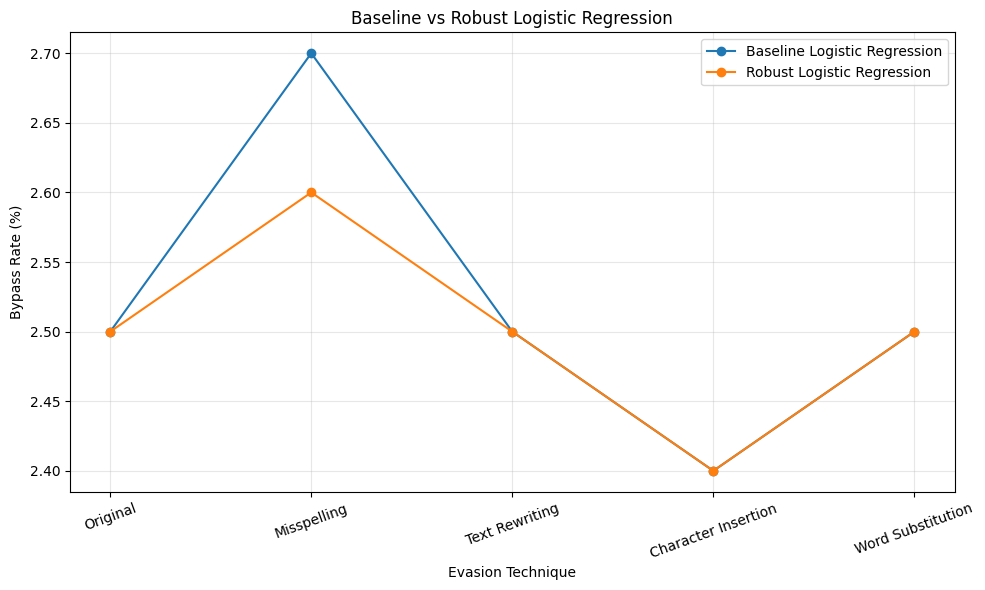

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

x = range(len(final_comparison))

plt.plot(
    x,
    final_comparison["Baseline Bypass Rate (%)"],
    marker="o",
    label="Baseline Logistic Regression"
)

plt.plot(
    x,
    final_comparison["Bypass Rate (%)"],
    marker="o",
    label="Robust Logistic Regression"
)

plt.xticks(
    x,
    final_comparison["Technique"],
    rotation=20
)

plt.xlabel("Evasion Technique")
plt.ylabel("Bypass Rate (%)")
plt.title("Baseline vs Robust Logistic Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Final baseline model performance comparison

baseline_model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy (%)": [
        97.62,
        95.83,
        97.37
    ],
    "Precision (%)": [
        97.13,
        95.45,
        96.76
    ],
    "Recall (%)": [
        97.50,
        95.10,
        97.30
    ],
    "F1 Score (%)": [
        97.31,
        95.27,
        97.03
    ],
    "False Negatives": [
        240,
        471,
        259
    ],
    "FNR (%)": [
        2.50,
        4.90,
        2.70
    ]
})

display(baseline_model_results)

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%),False Negatives,FNR (%)
0,Logistic Regression,97.62,97.13,97.5,97.31,240,2.5
1,Random Forest,95.83,95.45,95.1,95.27,471,4.9
2,XGBoost,97.37,96.76,97.3,97.03,259,2.7


In [ ]:
# Calculate evasion impact relative to the original baseline

evasion_impact = pd.DataFrame({
    "Technique": [
        "Misspelling",
        "Text Rewriting",
        "Character Insertion",
        "Word Substitution"
    ],
    "Baseline Bypass Rate (%)": [
        2.7,
        2.5,
        2.4,
        2.5
    ],
    "Change vs Original (percentage points)": [
        2.7 - 2.5,
        2.5 - 2.5,
        2.4 - 2.5,
        2.5 - 2.5
    ]
})

display(evasion_impact)

,Technique,Baseline Bypass Rate (%),Change vs Original (percentage points)
0,Misspelling,2.7,0.2
1,Text Rewriting,2.5,0.0
2,Character Insertion,2.4,-0.1
3,Word Substitution,2.5,0.0
